In [1]:
import os
import numpy as np
import pandas as pd
import scipy

from IPython.display import display
from tqdm.auto import tqdm

from nltk.corpus import stopwords

from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.decomposition import TruncatedSVD, LatentDirichletAllocation

from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer

import matplotlib.pyplot as plt

from src.data_utils import (
    remove_duplicate_texts,
    load_vader_words,
    load_gervader_words,
)

from src.preprocessing import run_preprocessing_loop

from src.model_utils import (
    vectorize,
    tune_lda_models,
    tune_lsa_models,
    build_sentiment_df,
    get_selected_topic_model,
    compute_dominant_topics,
    merge_topic_sentiment,
    build_topic_sentiment_summary
)

from src.visualization import (
    display_tuning_results,
    display_topic_model_summary,
    plot_topic_words,
    plot_topic_sizes,
    compare_topic_sizes,
    plot_topic_overlap_matrix,
    plot_topic_sentiment,
    show_reviews_for_topic
)

from src.styles import style_topic_sentiment

In [2]:
##########
# Data Import
##########

# Variable Definition
local_dir = "data"
path_reviews = f"{local_dir}/combined_reviews.csv"
stopword_path = "data/stopwords_custom.json"

# Import data to pandas dataframe
df_reviews = pd.read_csv(path_reviews)

df_reviews["language"] = df_reviews["origin"].map({
    "FragdenStaat": "de",
    "YELP": "en",
})

# Remove duplicate Requests
df_reviews = remove_duplicate_texts(df_reviews, text_col="review")


##########
# Stopword Definition
##########

# Import Sentiment Stopwords based on threshold
sia_en = SentimentIntensityAnalyzer()
de_thres = 2
en_thres = 1.5

vader_words_en = load_vader_words(sia_en, en_thres)
gervader_words_de = load_gervader_words("GerVADER/GERVaderLexicon.txt", de_thres)

# Build Basis-Dictionary
dict_stopw_default = {
    "iter_0": {
        "de_nltk_common": stopwords.words("german"),
        "de_vader_topic_only":gervader_words_de,
        "en_nltk_common": stopwords.words("english"),
        "en_vader_topic_only":vader_words_en,
        
    },
    "iter_1": {
        "de_custom_common": [],
        "de_custom_topic_only": [],
        "en_custom_common": [],
        "en_custom_topic_only": []
    }
}


=== Duplicate Removal ===
Before: 2000 rows
After:  1760 rows
Removed: 240 duplicates


In [5]:
##########
# Data PreProcessing
##########

top_n = 30       # Number of top tokens to display
n_process = 1    # Number of parallel processes (performance tuning)


# Run interactive preprocessing pipeline:
# - Loads or initializes stopword configuration (JSON)
# - Applies iterative stopword refinement (user-guided)
# - Cleans and tokenizes text for both topic modeling and sentiment analysis
# - Displays top token comparisons for validation
# - Repeats until user confirms final stopw

data_topic, data_sentiment, dict_stopw = run_preprocessing_loop(
    df_reviews=df_reviews,
    stopword_path=stopword_path,
    dict_stopw_default=dict_stopw_default,
    top_n=top_n,
    n_process=n_process
)


Stopword file found -> loading

Cleaning Data - Topic Modeling


Processing English: 100%|██████████████████████████████████████████████████████████| 1000/1000 [00:10<00:00, 94.61it/s]



Cleaning Data - Sentiment Analysis


Processing English: 100%|██████████████████████████████████████████████████████████| 1000/1000 [00:10<00:00, 95.14it/s]



Please review the top tokens and optionally extend them under 'iter_3' in data/stopwords_custom.json.
1 = JSON updated manually, start next iteration
2 = finished, continue with topic modeling


...


Cleaning Data - Sentiment Analysis


Processing English: 100%|██████████████████████████████████████████████████████████| 1000/1000 [00:15<00:00, 62.91it/s]



Please review the top tokens and optionally extend them under 'iter_7' in data/stopwords_custom.json.
1 = JSON updated manually, start next iteration
2 = finished, continue with topic modeling


Selection:  2



Final stopwords applied. Proceeding to topic modeling.


In [6]:
############
# Create Vectors with BoW & TF-IDF
############

# Separate Pipelines: Topic Modeling vs. Sentiment
print("Creating Vectors - Topic Modeling")
vectors_topic = {}
vectors_topic["bow_by_lang"] = vectorize(CountVectorizer, data_topic)
vectors_topic["tfidf_by_lang"] = vectorize(TfidfVectorizer, data_topic)

print("\nCreating Vectors - Sentiment Analysis")
vectors_sentiment = {}
vectors_sentiment["bow_by_lang"] = vectorize(CountVectorizer, data_sentiment)
vectors_sentiment["tfidf_by_lang"] = vectorize(TfidfVectorizer, data_sentiment)

Creating Vectors - Topic Modeling
de: 759 Dokumente, 3241 Features
en: 1000 Dokumente, 2266 Features
de: 759 Dokumente, 3241 Features
en: 1000 Dokumente, 2266 Features

Creating Vectors - Sentiment Analysis
de: 759 Dokumente, 3369 Features
en: 1000 Dokumente, 2749 Features
de: 759 Dokumente, 3369 Features
en: 1000 Dokumente, 2749 Features


In [35]:
############
# LDA/BoW - Model Tuning (en|de)
############

# Perform LDA parameter tuning per language using Grid Search.
# Explores multiple configurations to identify optimal topic models
# for each language-specific dataset.

# -----------------------------
# CONFIGURATION
# -----------------------------

# Full parameter grid (production mode - slow but thorough)
lda_config_prod = {
    "topic_grid": [5, 10, 15, 20],   # number of topics to test
    "alpha_grid": [0.01, 0.1],       # document-topic prior (sparsity control)
    "eta_grid": [0.01, 0.1],         # topic-word prior
    "max_iter_grid": [10, 20],       # number of training iterations
    "random_states": [42],
    "learning_method": "batch",      # batch learning for stable convergence
}

# Minimal parameter grid (test mode - fast execution)
lda_config_test = {
    "topic_grid": [10],          # single topic value
    "alpha_grid": [0.1],         # single prior
    "eta_grid": [0.1],           # single prior
    "max_iter_grid": [10],       # minimal iterations
    "random_states": [42],
    "learning_method": "batch",
}

# -----------------------------
# SWITCH BETWEEN MODES
# -----------------------------

TEST_MODE = False  # set to False for full tuning, True for Test

lda_config = lda_config_test if TEST_MODE else lda_config_prod


# -----------------------------
# RUN TUNING
# -----------------------------

# Dictionary to store tuning results separately for each language
lda_tuning_results_by_lang = {}

# Iterate over language-specific BOW vectorized datasets
for lang, data in vectors_topic["bow_by_lang"].items():

    # Apply selected configuration (test or production)
    lda_tuning_results_by_lang[lang] = tune_lda_models(
        data=data,
        topic_grid=lda_config["topic_grid"],
        alpha_grid=lda_config["alpha_grid"],
        eta_grid=lda_config["eta_grid"],
        max_iter_grid=lda_config["max_iter_grid"],
        random_states=lda_config["random_states"],
        learning_method=lda_config["learning_method"],
        lang=lang
    )

LDA Tuning (en): 100%|██████████████████| 32/32 [05:03<00:00,  9.48s/it, k=20, iter=20, coh=0.61, std=0.000, perp=1943]


In [36]:
############
# LDA/BoW - Tuning Validation (en|de)
############

# Define evaluation configuration for LDA tuning results.
# Each metric includes:
# - col: column name in the tuning results
# - weight: contribution to overall score
# - higher_is_better: optimization direction
# - good_quantile / bad_quantile: thresholds for scoring normalization
# - format: display formatting
lda_tuning_config = [
    {"col": "coherence",               "weight": 0.30, "higher_is_better": True,  "good_quantile": 0.75, "bad_quantile": 0.25, "format": "{:.2f}"},
    {"col": "coherence_std",           "weight": 0.10, "higher_is_better": False, "good_quantile": 0.25, "bad_quantile": 0.75, "format": "{:.2f}"},
    {"col": "perplexity",              "weight": 0.20, "higher_is_better": False, "good_quantile": 0.25, "bad_quantile": 0.75, "format": "{:.4f}"},
    {"col": "largest_topic_share",     "weight": 0.15, "higher_is_better": False, "good_quantile": 0.25, "bad_quantile": 0.75, "format": "{:.4f}"},
    {"col": "avg_word_overlap",        "weight": 0.10, "higher_is_better": False, "good_quantile": 0.25, "bad_quantile": 0.75, "format": "{:.4f}"},
]

# Evaluate and display LDA tuning results per language:
# - Computes weighted scores based on defined metrics
# - Ranks models by overall performance
# - Displays top configurations with formatted styling
lda_tuning_interpreted_by_lang = display_tuning_results(
    results_by_lang=lda_tuning_results_by_lang,
    tuning_config=lda_tuning_config,
    title="LDA/BoW Tuning",
    head_rows=15,  # Limit output to top-performing configurations
    hide_cols=[
        # Hide non-relevant or heavy columns for display clarity
        "topic_words", "topic_terms", "doc_topic_matrix", "model",
        "max_word_overlap", "largest_topic_share_std", "perplexity_std"
    ]
)


=== LDA/BoW Tuning (de) ===


,n_topics,alpha,eta,max_iter,coherence,coherence_std,perplexity,largest_topic_share,avg_word_overlap,best_seed,overall_score
27,20,0.010000,0.100000,20,2.20,0.00,1689.0544,0.0883,0.0073,42,0.7490
26,20,0.010000,0.100000,10,2.19,0.00,1701.9840,0.0896,0.0073,42,0.7369
31,20,0.100000,0.100000,20,2.19,0.00,1824.4356,0.1080,0.0076,42,0.7013
19,15,0.010000,0.100000,20,2.18,0.00,1716.2784,0.1186,0.0118,42,0.6864
22,15,0.100000,0.100000,10,2.18,0.00,1812.4876,0.1107,0.0102,42,0.6852
18,15,0.010000,0.100000,10,2.14,0.00,1732.0035,0.1107,0.0118,42,0.6646
15,10,0.100000,0.100000,20,2.17,0.00,1833.0147,0.1331,0.0094,42,0.6639
30,20,0.100000,0.100000,10,2.14,0.00,1846.1071,0.1054,0.0090,42,0.6590
11,10,0.010000,0.100000,20,2.18,0.00,1820.5701,0.1449,0.0118,42,0.6536
23,15,0.100000,0.100000,20,2.14,0.00,1794.6718,0.1107,0.0118,42,0.6534



=== LDA/BoW Tuning (en) ===


,n_topics,alpha,eta,max_iter,coherence,coherence_std,perplexity,largest_topic_share,avg_word_overlap,best_seed,overall_score
23,15,0.100000,0.100000,20,0.63,0.00,1798.1111,0.1620,0.1121,42,0.6595
31,20,0.100000,0.100000,20,0.61,0.00,1942.6804,0.1290,0.1233,42,0.6347
22,15,0.100000,0.100000,10,0.57,0.00,1846.0770,0.1570,0.1298,42,0.5866
15,10,0.100000,0.100000,20,0.55,0.00,1647.1103,0.1640,0.1312,42,0.5818
21,15,0.100000,0.010000,20,0.63,0.00,2847.7675,0.1480,0.1018,42,0.5750
30,20,0.100000,0.100000,10,0.55,0.00,1999.6101,0.1290,0.1179,42,0.5749
29,20,0.100000,0.010000,20,0.65,0.00,3297.3409,0.1060,0.1031,42,0.5652
19,15,0.010000,0.100000,20,0.54,0.00,1715.2892,0.1700,0.1400,42,0.5572
14,10,0.100000,0.100000,10,0.52,0.00,1706.0176,0.1620,0.1412,42,0.5333
13,10,0.100000,0.010000,20,0.58,0.00,2456.2266,0.1640,0.1261,42,0.5301


In [37]:
############
# LSA/TF-IDF - Model Tuning (en|de)
############

# Perform parameter tuning for LSA (Latent Semantic Analysis)
# on TF-IDF features, evaluated separately for each language.
# The goal is to identify optimal semantic dimensionality and
# stable decomposition settings.


# Dictionary to store tuning results per language (e.g. 'en', 'de')
lsa_tuning_results_by_lang = {}

# Iterate over language-specific TF-IDF vectorized datasets
for lang, data in vectors_topic["tfidf_by_lang"].items():

    # Perform LSA model tuning using different hyperparameter combinations:
    # - topic_grid: number of latent semantic components (topics)
    #   higher values → finer topic separation, but harder interpretation
    # - n_iter_grid: number of SVD iterations
    #   more iterations → better convergence and stability, but slower runtime
    # - random_state: fixed seed for reproducibility
    # - lang: used for logging or progress tracking
    lsa_tuning_results_by_lang[lang] = tune_lsa_models(
        data=data,
        topic_grid=[10, 20, 30],
        n_iter_grid=[10, 20, 30],
        random_state=42,
        lang=lang
    )

LSA Tuning (en): 100%|████████████████████████████████| 9/9 [00:33<00:00,  3.78s/it, k=30, iter=30, coh=0.42, var=0.15]


In [38]:
############
# LSA/TF-IDF - Tuning Validation (en|de)
############

# Define evaluation configuration for LSA tuning results.
# Each metric contributes to the final score using a weighted scheme:
# - col: metric name in the tuning results DataFrame
# - weight: importance of the metric in overall ranking
# - higher_is_better: optimization direction
# - good_quantile / bad_quantile: thresholds used for normalization/scoring
# - format: display formatting for readability
lsa_tuning_config = [
    {"col": "avg_word_overlap",     "weight": 0.16, "higher_is_better": False, "good_quantile": 0.25, "bad_quantile": 0.75, "format": "{:.4f}"},
    {"col": "coherence",            "weight": 0.42, "higher_is_better": True,  "good_quantile": 0.75, "bad_quantile": 0.25, "format": "{:.4f}"},
    {"col": "explained_variance",   "weight": 0.17, "higher_is_better": True,  "good_quantile": 0.75, "bad_quantile": 0.25, "format": "{:.4f}"},
    {"col": "largest_topic_share",  "weight": 0.25, "higher_is_better": False, "good_quantile": 0.25, "bad_quantile": 0.75, "format": "{:.4f}"},
]

# Evaluate and display LSA tuning results for each language:
# - Computes normalized and weighted scores based on the configuration
# - Ranks model configurations by overall performance
# - Displays the top results with formatted styling for comparison
lsa_tuning_interpreted_by_lang = display_tuning_results(
    results_by_lang=lsa_tuning_results_by_lang,
    tuning_config=lsa_tuning_config,
    title="LSA/TF-IDF Tuning",
    head_rows=10,  # Limit output to top-performing configurations
    hide_cols=[
        # Hide large or non-essential columns to improve readability
        "topic_words", "topic_terms", "doc_topic_matrix", "model"
    ]
)


=== LSA/TF-IDF Tuning (de) ===


,n_topics,n_iter,coherence,largest_topic_share,explained_variance,avg_word_overlap,max_word_overlap,overall_score
2,10,30,2.9863,0.5876,0.1107,0.0159,0.111111,0.5829
1,10,20,2.9863,0.5889,0.1107,0.0159,0.111111,0.5820
0,10,10,2.9735,0.5916,0.1106,0.0159,0.111111,0.5729
8,30,30,2.3241,0.2609,0.2039,0.0423,0.666667,0.5008
7,30,20,2.3142,0.2582,0.2038,0.0421,0.666667,0.4980
6,30,10,2.2260,0.2503,0.2036,0.0446,0.666667,0.4429
4,20,20,2.4247,0.3808,0.1612,0.0495,0.666667,0.3564
5,20,30,2.4247,0.3821,0.1612,0.0495,0.666667,0.3554
3,20,10,2.4145,0.3874,0.1611,0.0478,0.666667,0.3541



=== LSA/TF-IDF Tuning (en) ===


,n_topics,n_iter,coherence,largest_topic_share,explained_variance,avg_word_overlap,max_word_overlap,overall_score
8,30,30,0.4176,0.4410,0.1458,0.1256,0.666667,1.0000
7,30,20,0.4176,0.4460,0.1458,0.1256,0.666667,0.9938
6,30,10,0.3940,0.4480,0.1456,0.1307,0.666667,0.8472
5,20,30,0.3904,0.5060,0.1073,0.1489,0.666667,0.6463
4,20,20,0.3877,0.5050,0.1073,0.1517,0.666667,0.6276
3,20,10,0.3711,0.5040,0.1071,0.1534,0.666667,0.5303
2,10,30,0.3480,0.6430,0.0622,0.2200,0.666667,0.0221
0,10,10,0.3441,0.6420,0.0622,0.2170,0.666667,0.0064
1,10,20,0.3441,0.6430,0.0622,0.2170,0.666667,0.0051


In [40]:
############
# Result Validation/ Model Selection
############

### Top Word Comparison of the Top X Models (EN | DE)
# Displays the most important words for each topic.
# Purpose:
# - Are the topics semantically coherent and interpretable?
# - Are there generic or poorly defined topics?
# - Are the topics redundant or clearly distinct?
display_topic_model_summary(
    tuning_interpreted_by_lang=lsa_tuning_interpreted_by_lang,
    model_name="LSA/TF-IDF",
    top_k=6
)

display_topic_model_summary(
    tuning_interpreted_by_lang=lda_tuning_interpreted_by_lang,
    model_name="LDA/BoW",
    top_k=6
)



=== Top 6 LSA/TF-IDF Modelle (de) ===

--- Rang 1 | Index 2 | Score: 0.5829 | Topics: 10 ---


,Topic 1,Topic 2,Topic 3,Topic 4,Topic 5,Topic 6,Topic 7,Topic 8,Topic 9,Topic 10
0,kosten (11.4%),fach (12.2%),schlachthof (11.3%),gemeinde (21.9%),maßnahme (14.0%),schlachtbetrieb (23.4%),arzt (17.0%),unternehmen (10.4%),volumen (15.7%),gemeinde (21.4%)
1,kosten aufwand (10.2%),erwartungshorizonte (11.4%),dokumentiert geschlachtet (10.1%),projekt (19.0%),projekt (11.6%),genehmigungsbescheide schlachtbetrieb (22.1%),meldung (11.7%),amtlich genussuntauglich (10.3%),genehmigt (11.5%),herausgabe (10.2%)
2,aufwand (10.0%),aufgabe erwartungshorizonte (11.4%),geschlachtet (10.1%),verfolgen (11.1%),umweltinformation bund (9.4%),genehmigungsbescheide (22.1%),unterweisung (10.4%),genussuntauglich erklären (10.3%),gemeinde (11.4%),bayrischzell (10.2%)
3,aufwand gebühr (9.9%),aufgabe (11.3%),geschlachtet tier (10.1%),verfahrensstand (7.2%),bund gesundheitsbezogen (9.4%),straße (10.4%),unerwünscht (10.2%),tier überwachung (10.3%),wasserentnahme (9.3%),hiermit (10.1%)
4,bürgeranfrage behandeln (9.9%),erwartungshorizonte fach (10.6%),tierart (10.1%),baubeginn (7.2%),datenschutzgesetz umweltinformation (9.4%),schlachthof (7.2%),medizinisch (10.2%),genussuntauglich (10.3%),bayrischzell (9.1%),hiermit herausgabe (9.1%)
5,behandeln (9.8%),fragdenstaat angefragt (9.2%),abgeschlossen berichtsjahr (9.7%),bebauungsplanverfahr (7.0%),gesundheitsbezogen bürgeranfrage (9.3%),hof (4.0%),verdacht (9.2%),postanschrift (9.8%),stoff (9.0%),betrieb (9.1%)
6,bürgeranfrage (9.8%),angefragt gewähren (9.2%),berichtsjahr überwachung (9.7%),bebauungsplan (6.8%),gemeinde (9.3%),augsburg (3.0%),arzneimittelwirkung (7.8%),unten betroffen (9.6%),enthalten (8.8%),projekt (7.9%)
7,gebühr (9.8%),gewähren (9.0%),tier (9.7%),gemarkung (6.7%),bürgeranfrage behandeln (9.3%),metzgerei (2.7%),verdacht impfnebenwirkung (7.8%),erfragen stimmen (9.6%),wassereinleitung (8.4%),lebensmittelrechtlich (7.7%)
8,umweltinformation (9.7%),fragdenstaat (8.2%),differenzieren tierart (9.6%),aktueller verfahrensstand (6.7%),bereich (9.1%),aschaffenburg (2.6%),unerwünscht arzneimittelwirkung (7.8%),betroffen unternehmen (9.6%),enthalten stoff (8.4%),betriebsüberprüfung (7.1%)
9,datenschutzgesetz umweltinformation (9.5%),angefragt (7.6%),tier differenzieren (9.6%),aktueller (6.5%),stadt (9.1%),genehmigungsbescheid (2.5%),impfnebenwirkung (7.8%),erfragen (9.6%),temperatur enthalten (8.4%),lebensmittelrechtlich betriebsüberprüfung (7.1%)



--- Rang 2 | Index 1 | Score: 0.5820 | Topics: 10 ---


,Topic 1,Topic 2,Topic 3,Topic 4,Topic 5,Topic 6,Topic 7,Topic 8,Topic 9,Topic 10
0,kosten (11.4%),fach (12.2%),schlachthof (11.3%),gemeinde (21.9%),maßnahme (14.0%),schlachtbetrieb (23.4%),arzt (17.0%),unternehmen (10.4%),volumen (15.7%),gemeinde (21.4%)
1,kosten aufwand (10.2%),erwartungshorizonte (11.4%),dokumentiert geschlachtet (10.1%),projekt (19.0%),projekt (11.6%),genehmigungsbescheide schlachtbetrieb (22.1%),meldung (11.7%),genussuntauglich erklären (10.3%),genehmigt (11.5%),herausgabe (10.3%)
2,aufwand (10.0%),aufgabe erwartungshorizonte (11.4%),geschlachtet (10.1%),verfolgen (11.1%),umweltinformation bund (9.4%),genehmigungsbescheide (22.1%),unterweisung (10.4%),tier überwachung (10.3%),gemeinde (11.4%),bayrischzell (10.2%)
3,aufwand gebühr (9.9%),aufgabe (11.3%),geschlachtet tier (10.1%),verfahrensstand (7.2%),bund gesundheitsbezogen (9.4%),straße (10.4%),unerwünscht (10.2%),genussuntauglich (10.3%),wasserentnahme (9.3%),hiermit (10.2%)
4,bürgeranfrage behandeln (9.9%),erwartungshorizonte fach (10.6%),tierart (10.1%),baubeginn (7.2%),datenschutzgesetz umweltinformation (9.4%),schlachthof (7.2%),medizinisch (10.2%),amtlich genussuntauglich (10.3%),bayrischzell (9.1%),hiermit herausgabe (9.1%)
5,behandeln (9.8%),fragdenstaat angefragt (9.2%),abgeschlossen berichtsjahr (9.7%),bebauungsplanverfahr (7.0%),gesundheitsbezogen bürgeranfrage (9.3%),hof (4.0%),verdacht (9.2%),postanschrift (9.8%),stoff (9.0%),betrieb (9.1%)
6,bürgeranfrage (9.8%),angefragt gewähren (9.2%),berichtsjahr überwachung (9.7%),bebauungsplan (6.8%),gemeinde (9.3%),augsburg (3.0%),arzneimittelwirkung (7.8%),finden unten (9.6%),enthalten (8.7%),projekt (7.9%)
7,gebühr (9.8%),gewähren (9.0%),tier (9.7%),gemarkung (6.7%),bürgeranfrage behandeln (9.3%),metzgerei (2.7%),verdacht impfnebenwirkung (7.8%),postanschrift finden (9.6%),enthalten stoff (8.4%),lebensmittelrechtlich (7.7%)
8,umweltinformation (9.7%),fragdenstaat (8.2%),differenzieren tierart (9.6%),aktueller verfahrensstand (6.7%),bereich (9.1%),aschaffenburg (2.6%),unerwünscht arzneimittelwirkung (7.8%),jeglicher sonstig (9.6%),volumen temperatur (8.4%),lebensmittelrechtlich betriebsüberprüfung (7.1%)
9,datenschutzgesetz umweltinformation (9.5%),angefragt (7.6%),tier differenzieren (9.6%),aktueller (6.5%),stadt (9.1%),genehmigungsbescheid (2.5%),impfnebenwirkung (7.8%),stimmen gesetzlich (9.6%),temperatur (8.4%),betriebsüberprüfung (7.1%)



--- Rang 3 | Index 0 | Score: 0.5729 | Topics: 10 ---


...

,Topic 1,Topic 2,Topic 3,Topic 4,Topic 5,Topic 6,Topic 7,Topic 8,Topic 9,Topic 10
0,pizza (18.8%),wine (13.2%),food (28.9%),food (25.5%),food (18.0%),room (21.9%),order (17.7%),food (19.3%),burger (27.6%),car (22.4%)
1,food (14.6%),order (13.1%),service (14.3%),restaurant (10.3%),table (11.7%),hair (16.4%),restaurant (11.7%),tour (17.0%),wait (10.9%),service (16.7%)
2,bar (11.2%),food (10.4%),order (13.6%),order (9.4%),breakfast (10.0%),hotel (12.4%),price (11.6%),service (10.9%),experience (8.5%),customer (12.2%)
3,beer (9.6%),live (10.4%),chicken (11.0%),fresh (8.7%),eat (9.4%),staff (9.7%),night (10.0%),ice (8.6%),fry (8.4%),call (10.3%)
4,sushi (8.9%),thai (9.6%),wait (7.4%),salad (8.7%),order (9.1%),stay (8.4%),experience (9.2%),order (8.5%),menu (8.1%),location (8.2%)
5,drink (8.3%),flavor (9.1%),meal (6.5%),taco (8.5%),sandwich (8.8%),nail (7.8%),wait (9.1%),table (8.1%),drink (8.1%),staff (6.5%)
6,order (8.0%),eat (8.6%),table (4.8%),service (7.5%),coffee (8.6%),wait (6.0%),service (8.6%),cream (7.6%),roast (7.6%),give (6.2%)
7,menu (7.5%),beer (8.5%),lunch (4.7%),price (7.3%),chicken (8.6%),cut (5.9%),seafood (7.9%),wait (6.9%),table (7.6%),buy (6.2%)
8,staff (6.9%),sauce (8.5%),fry (4.5%),staff (7.1%),steak (8.3%),store (5.8%),food (7.5%),restaurant (6.7%),bar (6.9%),shop (5.7%)
9,service (6.4%),shrimp (8.4%),drink (4.4%),lunch (7.0%),staff (7.5%),salon (5.6%),stay (6.7%),ice cream (6.4%),birthday (6.5%),sale (5.5%)



--- Rang 5 | Index 21 | Score: 0.5750 | Topics: 15 ---


,Topic 1,Topic 2,Topic 3,Topic 4,Topic 5,Topic 6,Topic 7,Topic 8,Topic 9,Topic 10,Topic 11,Topic 12,Topic 13,Topic 14,Topic 15
0,bar (21.4%),pizza (32.9%),food (32.4%),food (23.6%),food (18.2%),hair (26.6%),order (13.7%),service (14.8%),burger (18.7%),car (26.8%),order (20.8%),room (26.1%),food (18.8%),burger (19.9%),food (29.2%)
1,drink (15.3%),wine (11.4%),service (12.5%),price (11.4%),breakfast (10.8%),nail (12.7%),restaurant (12.6%),cream (12.0%),roast (12.3%),service (16.2%),food (17.7%),hotel (17.9%),order (16.2%),fry (13.5%),service (12.1%)
2,bartender (10.3%),burger (10.2%),wait (8.8%),menu (10.6%),eat (10.4%),owner (9.8%),seafood (11.9%),ice (11.1%),wait (11.4%),customer (11.4%),table (9.1%),tour (13.3%),salad (9.7%),fish (10.6%),chicken (10.7%)
3,sit (8.4%),order (10.2%),table (8.4%),staff (8.8%),steak (10.2%),salon (9.1%),experience (11.8%),walk (9.9%),menu (10.3%),sale (8.2%),fresh (8.1%),stay (9.9%),sushi (9.4%),taco (9.1%),order (9.3%)
4,serve (8.1%),thai (6.9%),fry (7.9%),restaurant (8.6%),order (9.4%),wait (7.5%),wait (11.5%),ice cream (9.2%),star (8.6%),roll (6.8%),wait (8.0%),staff (8.9%),rice (8.6%),food (9.0%),eat (8.8%)
5,beer (7.9%),service (6.0%),order (6.4%),salad (8.3%),potato (8.8%),food (7.4%),wedding (8.8%),small (9.1%),store (8.5%),sushi (6.8%),menu (7.6%),stop (5.2%),lunch (8.5%),service (8.8%),price (7.1%)
6,service (7.5%),fresh (5.8%),crab (6.2%),home (7.6%),make (8.6%),staff (7.1%),night (8.2%),coffee (8.9%),table (8.2%),customer service (6.2%),bread (7.4%),guest (5.1%),fresh (7.9%),chicken (8.5%),staff (6.0%)
7,staff (7.1%),live (5.7%),bar (6.0%),philly (7.2%),service (8.4%),cut (7.1%),away (7.5%),drive (8.7%),coffee (7.4%),shop (5.9%),service (7.3%),desk (4.6%),price (7.5%),bit (7.6%),flavor (5.8%)
8,taste (7.0%),beer (5.4%),restaurant (5.9%),wine (7.0%),salad (7.6%),check (6.4%),cake (7.2%),order (8.5%),selection (7.3%),oil (5.8%),drink (7.1%),check (4.6%),staff (6.7%),order (6.5%),restaurant (5.5%)
9,price (6.9%),shrimp (5.4%),drink (5.4%),italian (6.9%),pancake (7.5%),pick (6.3%),dog (6.7%),woman (7.8%),cake (7.2%),price (5.8%),beer (6.9%),close (4.4%),service (6.7%),fresh (6.5%),meal (5.4%)



--- Rang 6 | Index 30 | Score: 0.5749 | Topics: 20 ---


,Topic 1,Topic 2,Topic 3,Topic 4,Topic 5,Topic 6,Topic 7,Topic 8,Topic 9,Topic 10,Topic 11,Topic 12,Topic 13,Topic 14,Topic 15,Topic 16,Topic 17,Topic 18,Topic 19,Topic 20
0,bar (18.0%),wine (16.9%),food (24.7%),lunch (12.9%),burger (21.4%),hair (26.4%),order (19.7%),ice (12.7%),wait (19.6%),chicken (20.0%),food (18.2%),room (20.0%),food (28.3%),taco (18.0%),food (28.1%),order (17.5%),food (20.1%),pizza (40.1%),service (21.5%),car (22.2%)
1,drink (10.5%),food (13.2%),cheese (9.7%),food (12.8%),food (14.3%),nail (13.1%),service (14.4%),cream (12.0%),burger (13.2%),flavor (11.8%),order (16.6%),tour (19.6%),order (12.9%),chicken (11.7%),service (11.6%),stay (12.9%),drink (13.1%),food (11.1%),food (13.7%),service (15.3%)
2,cocktail (10.3%),live (10.1%),lunch (9.7%),salad (11.8%),breakfast (11.2%),food (10.2%),night (11.5%),food (11.7%),roast (11.0%),location (11.5%),service (10.7%),hotel (17.8%),staff (10.4%),fish (11.5%),order (11.2%),room (11.8%),order (12.7%),order (8.9%),sushi (10.4%),customer (11.7%)
3,menu (10.3%),roll (9.3%),fry (8.7%),staff (9.8%),sandwich (9.3%),salon (9.6%),restaurant (8.7%),coffee (11.1%),menu (9.8%),car (9.7%),beer (9.1%),stop (7.4%),service (9.5%),fry (10.3%),eat (9.5%),food (9.8%),store (11.2%),burger (8.6%),staff (9.7%),call (9.4%)
4,sit (9.5%),eat (9.3%),price (8.5%),cheese (9.7%),staff (7.8%),staff (9.5%),price (8.5%),ice cream (10.7%),fry (8.7%),jen (8.6%),fresh (8.5%),staff (6.7%),fresh (8.7%),food (9.1%),restaurant (7.4%),service (9.6%),sushi (10.8%),service (7.2%),steak (8.2%),food (9.2%)
5,staff (8.8%),restaurant (8.8%),sandwich (8.3%),small (9.5%),serve (7.5%),owner (9.1%),seafood (8.4%),service (10.3%),location (8.3%),room (8.5%),drink (8.1%),drink (6.5%),price (7.5%),burger (8.5%),chicken (7.0%),bar (8.3%),price (9.3%),beer (5.5%),price (7.7%),oil (6.9%)
6,bartender (8.7%),music (8.6%),salad (8.1%),order (9.0%),bar (7.4%),wait (6.9%),wedding (7.4%),fresh (9.5%),experience (8.0%),return (7.9%),bar (7.4%),experience (6.0%),restaurant (6.8%),eat (8.5%),drink (6.3%),bread (8.2%),service (6.5%),star (5.5%),crab (7.4%),table (6.7%)
7,burger (8.2%),guy (8.4%),wait (8.0%),service (8.9%),menu (7.2%),lady (5.6%),experience (7.4%),table (7.9%),sandwich (7.9%),wedding (7.4%),wait (7.3%),food (5.9%),rice (6.2%),order (7.8%),wait (6.3%),line (7.6%),small (5.5%),table (4.5%),cut (7.3%),job (6.6%)
8,pepper (7.9%),order (8.3%),meal (7.2%),star (8.3%),coffee (7.0%),service (4.9%),cake (7.3%),small (7.3%),whiskey (6.9%),bird (7.4%),table (7.2%),huge (5.1%),event (5.2%),bit (7.4%),meal (6.3%),worth (7.2%),sit (5.4%),cheese (4.5%),rock (7.1%),order (6.3%)
9,street (7.7%),give (7.0%),potato (7.1%),tomato (7.3%),stop (6.9%),chip (4.7%),wait (6.6%),wait (6.8%),pork (6.6%),bean (7.3%),different (6.8%),big (5.0%),selection (4.5%),big (7.3%),staff (6.1%),taste (7.2%),pay (5.4%),crust (4.2%),game (6.9%),experience (5.7%)



=== Model idx 2 | 10 Topics | Score: 0.5829 ===


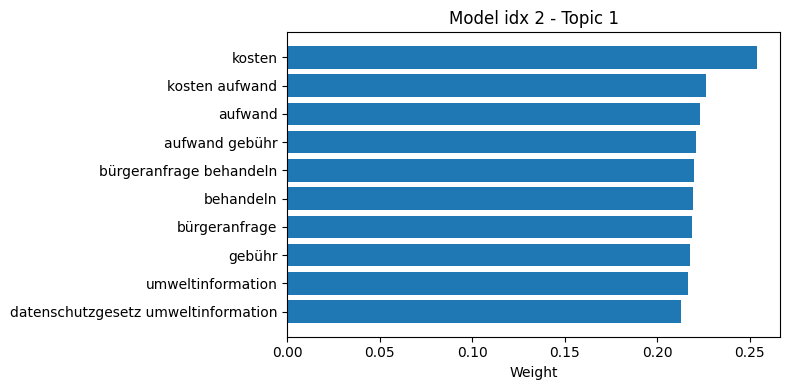

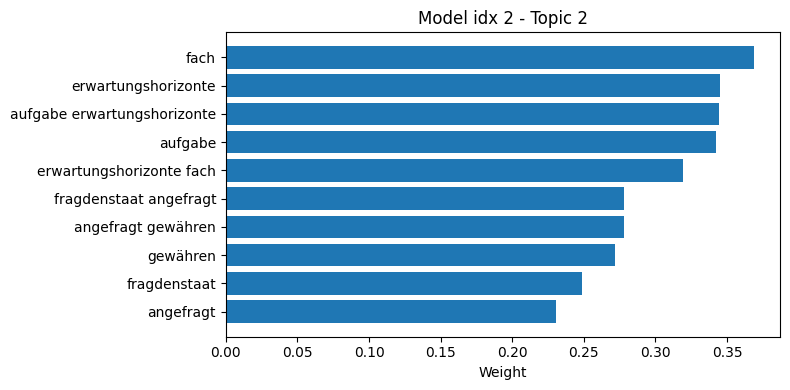

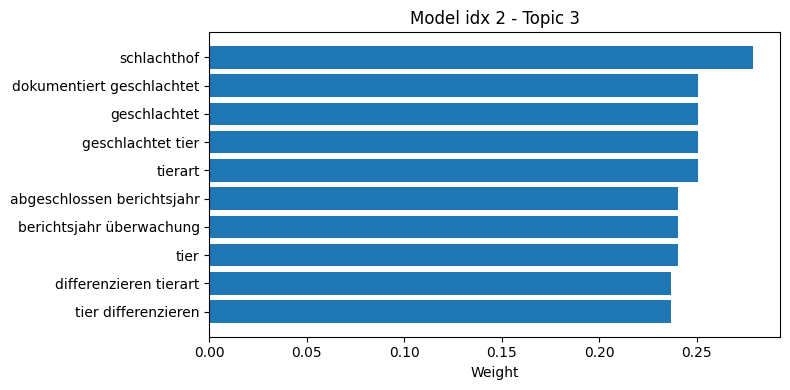

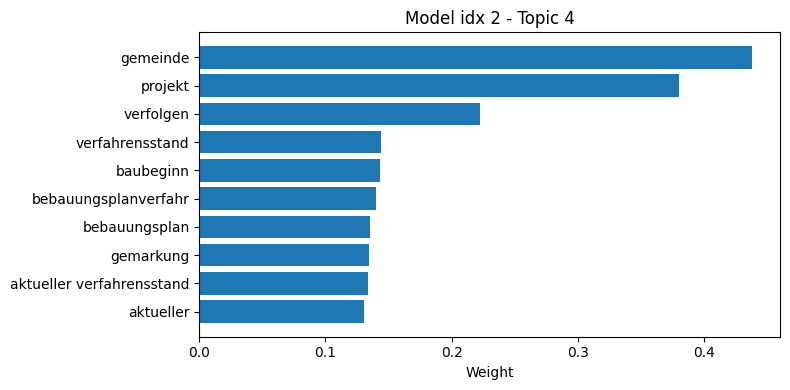

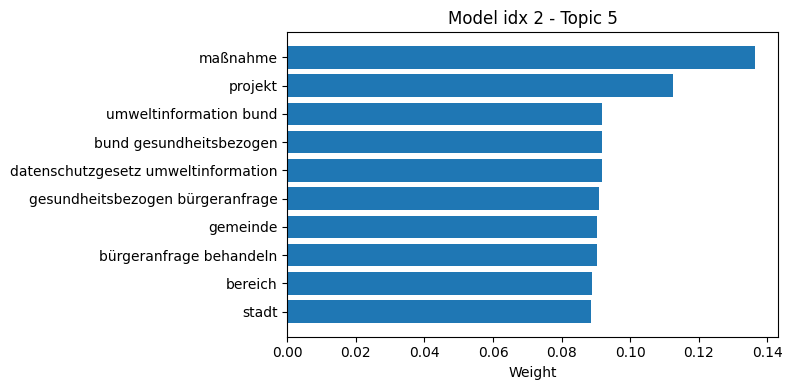

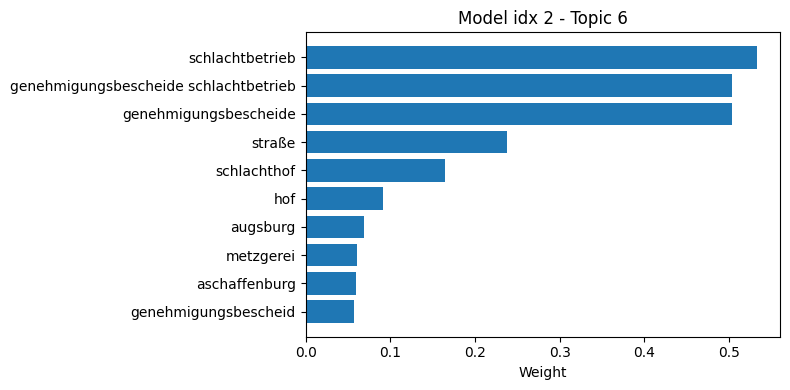

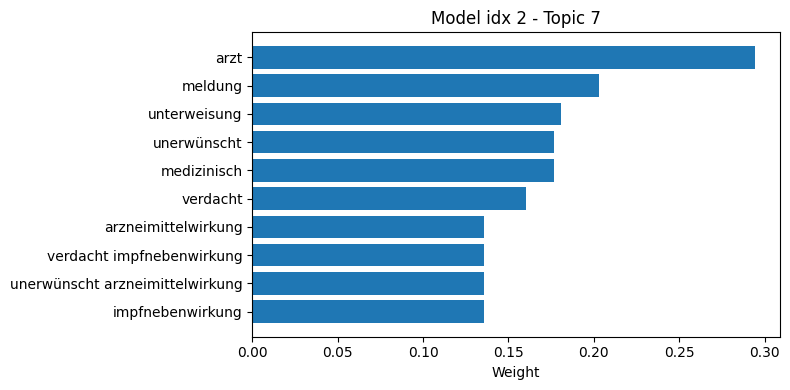

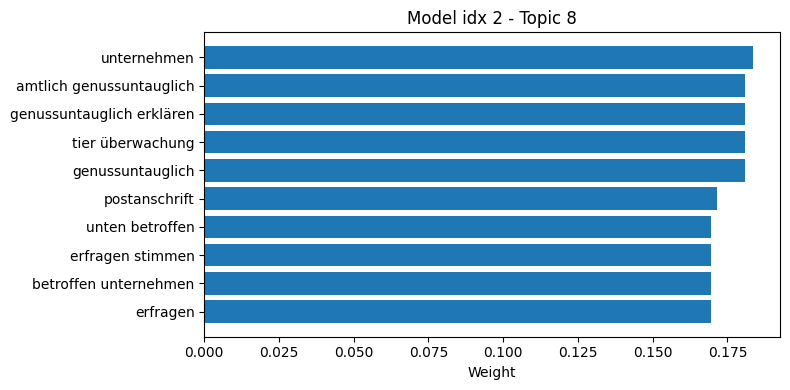

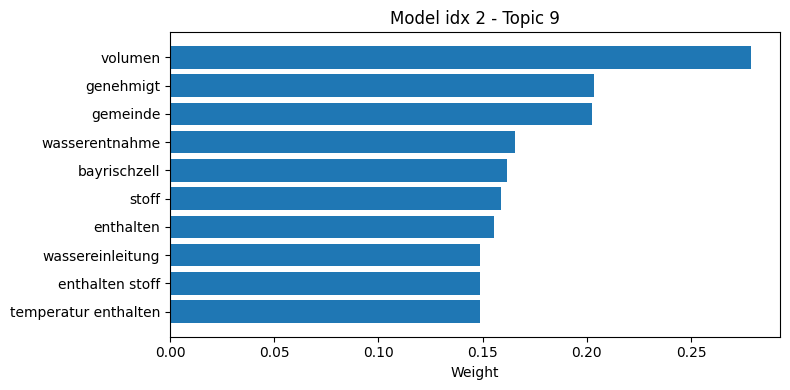

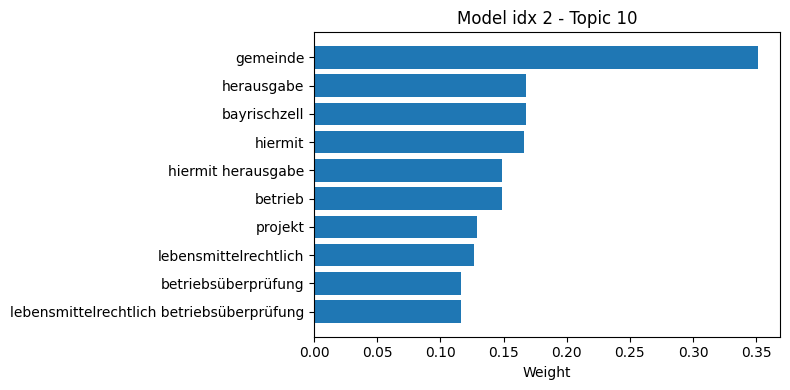


=== Model idx 1 | 10 Topics | Score: 0.5820 ===


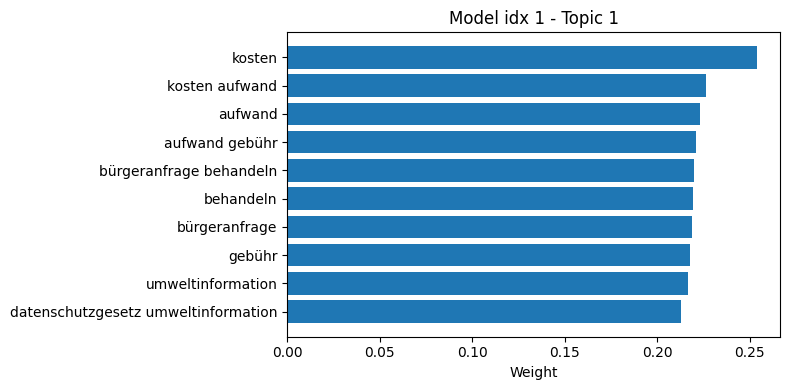

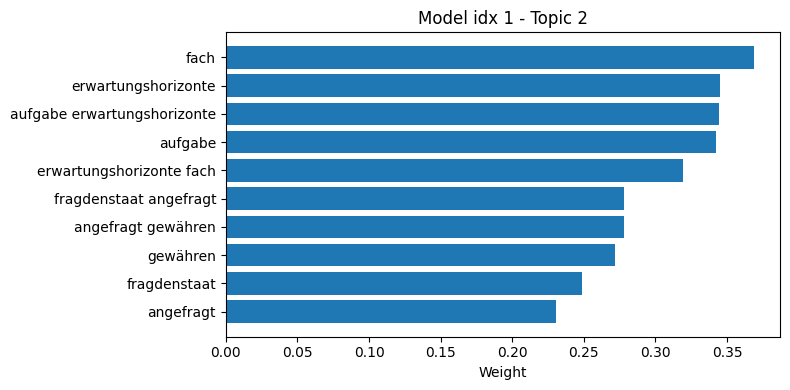

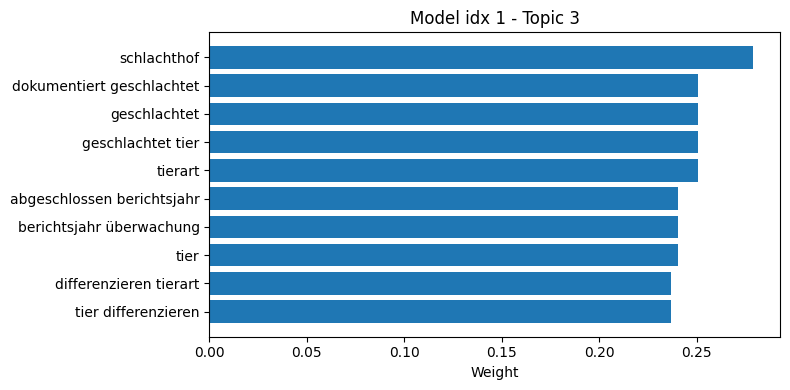

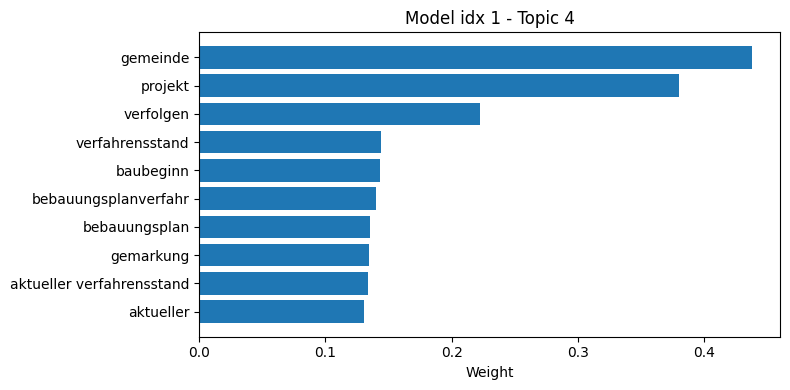

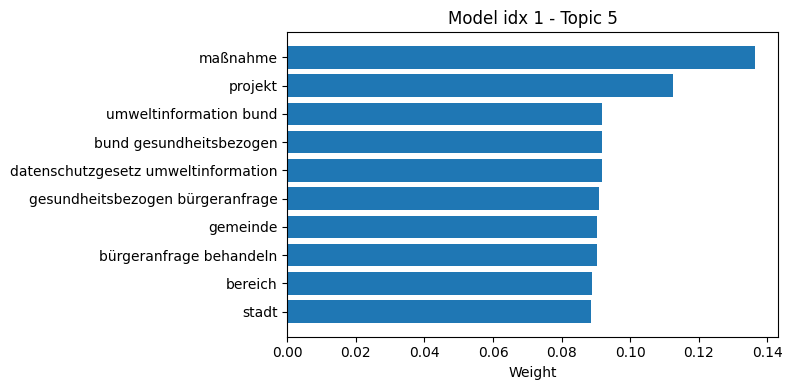

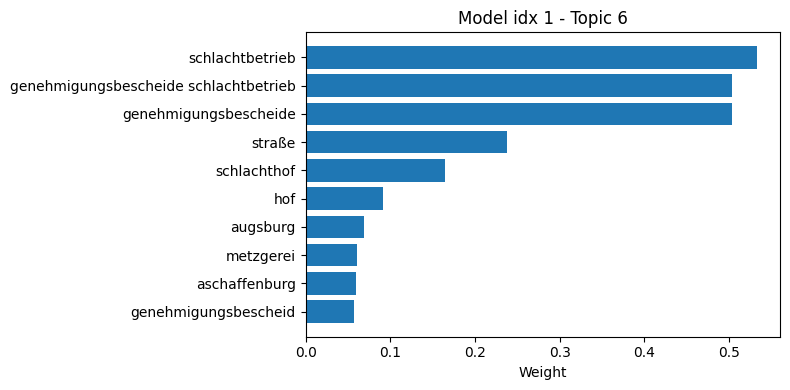

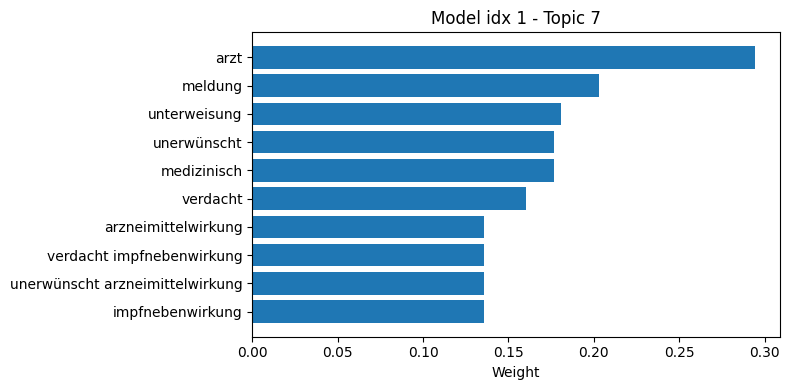

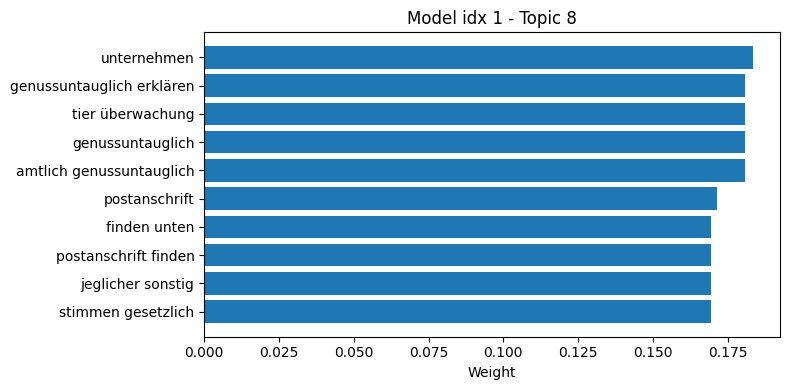

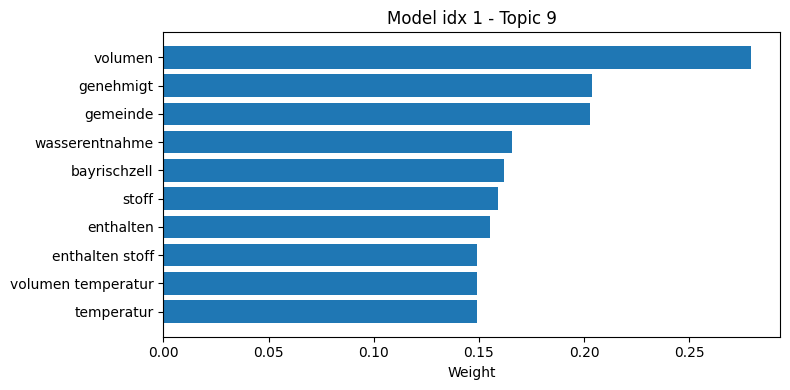

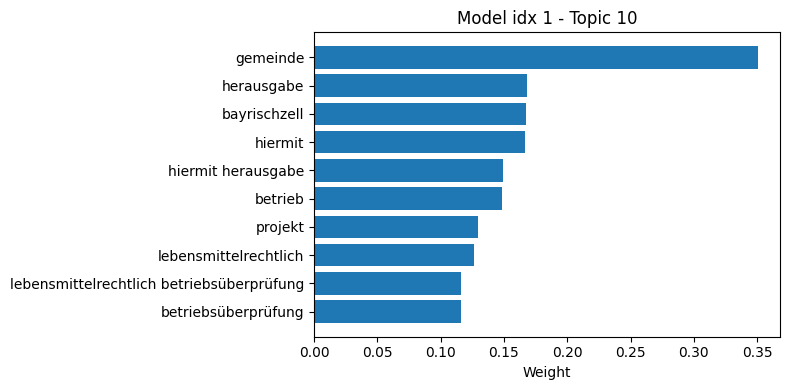


=== Model idx 0 | 10 Topics | Score: 0.5729 ===


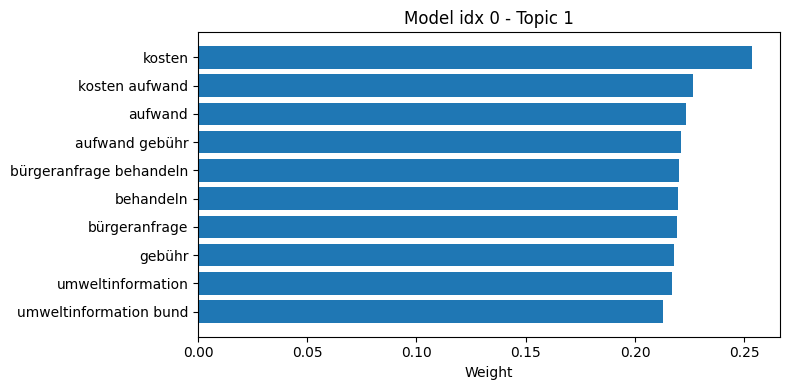

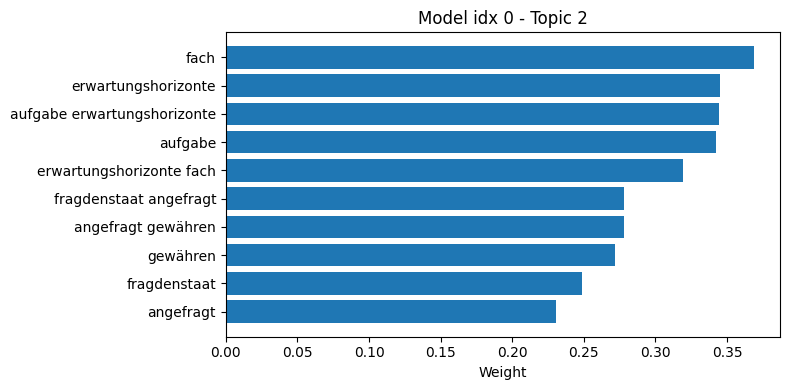

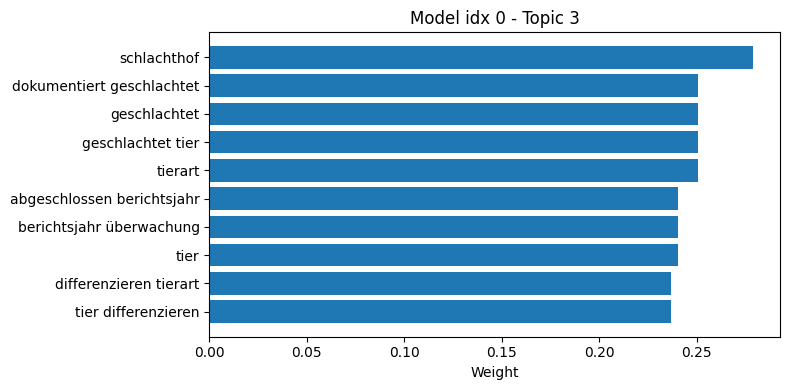

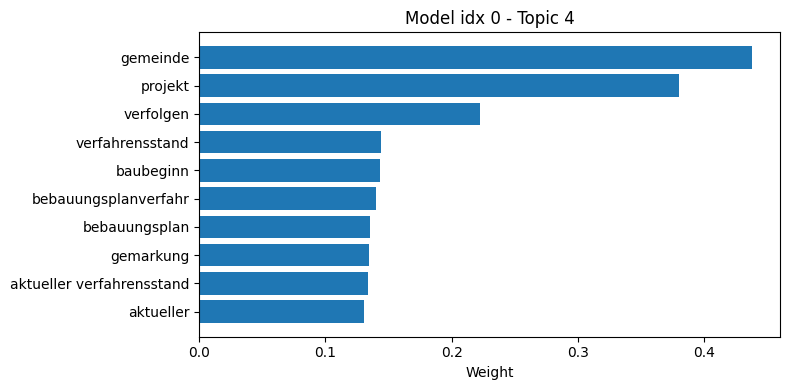

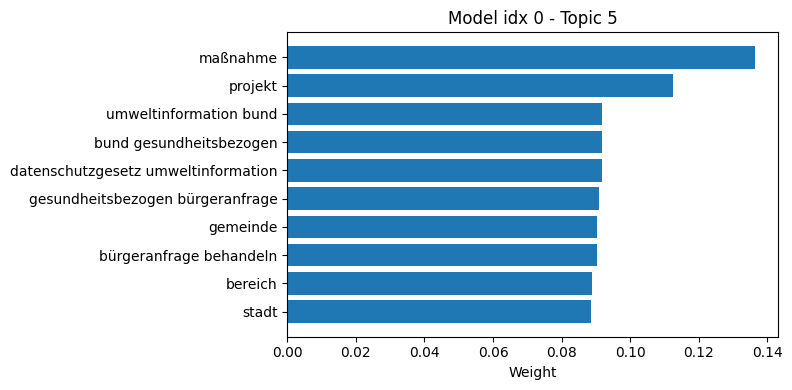

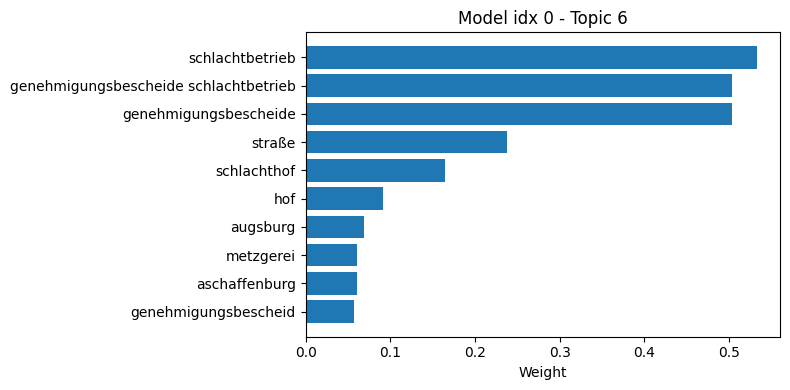

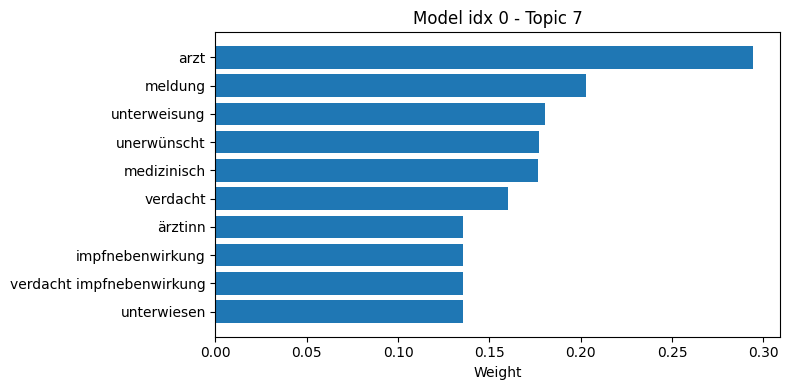

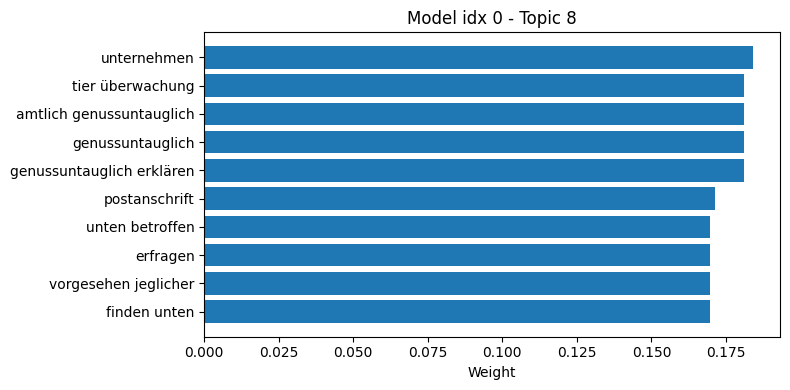

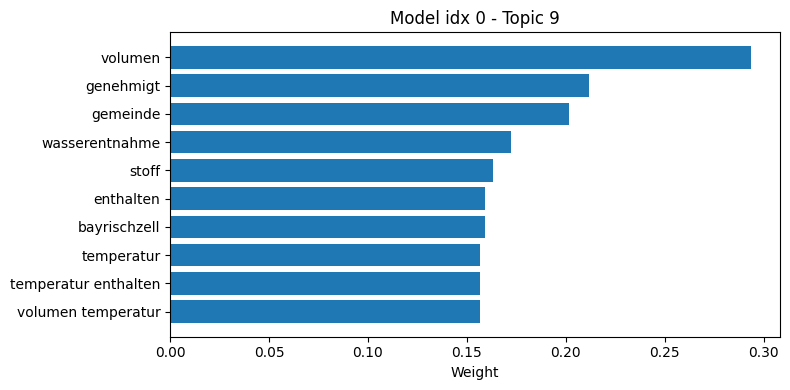

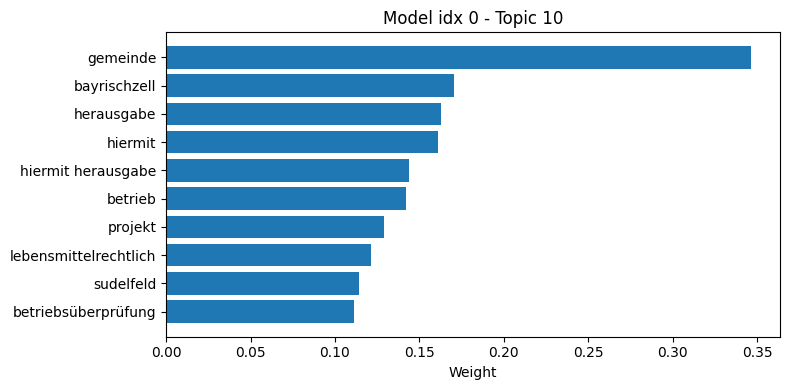

In [41]:
### Topic Visualization of the Selected Model
# Displays the keyword distribution of a selected model.
# Purpose:
# - Validate the qualitative topic structure.
# - Assess the balance of document assignments across topics.
# - Identify dominant, underrepresented, or empty topics.

plot_topic_words(
    lsa_tuning_interpreted_by_lang["de"].iloc[:3]
)

In [42]:
### Topic Size Comparison of Top Models (Table)
# Displays the number of documents assigned to each topic
# for all candidate models.
# Purpose:
# - Assess the balance of topic distributions.
# - Identify dominant or underrepresented topics.
# - Detect empty or nearly empty topics.
# - Support qualitative model selection.
    
display(compare_topic_sizes(
    lsa_tuning_interpreted_by_lang["de"],
    method="lsa",
    title="=== LSA/TF-IDF Topic-Größen (DE) ==="
))

display(compare_topic_sizes(
    lsa_tuning_interpreted_by_lang["de"],
    method="lda",
    title="=== LDA/BoW Topic-Größen (DE) ==="
))

display(compare_topic_sizes(
    lsa_tuning_interpreted_by_lang["en"],
    method="lsa",
    title="=== LSA/TF-IDF Topic-Größen (EN) ==="
))

display(compare_topic_sizes(
    lsa_tuning_interpreted_by_lang["en"],
    method="lda",
    title="=== LDA/BoW Topic-Größen (EN) ==="
))

=== LSA/TF-IDF Topic-Größen (DE) ===


,Topic,Docs (Model 2),Docs (Model 1),Docs (Model 0),Docs (Model 8),Docs (Model 7),Docs (Model 6),Docs (Model 4),Docs (Model 5),Docs (Model 3)
0,0,100,100,100,85,85,85,87,87,87
1,1,24,24,24,24,24,24,24,24,24
2,2,28,28,28,26,26,26,26,26,26
3,3,39,39,40,29,29,30,34,34,34
4,4,446,447,449,198,196,190,289,290,294
5,5,27,27,27,18,18,18,22,22,22
6,6,8,8,8,7,7,7,7,7,7
7,7,16,14,14,11,11,11,11,11,11
8,8,25,26,20,7,7,7,8,8,7
9,9,46,46,49,10,10,8,16,16,16


=== LDA/BoW Topic-Größen (DE) ===


,Topic,Docs (Model 2),Docs (Model 1),Docs (Model 0),Docs (Model 8),Docs (Model 7),Docs (Model 6),Docs (Model 4),Docs (Model 5),Docs (Model 3)
0,0,100,100,100,86,87,86,88,88,89
1,1,25,25,25,24,24,24,24,24,24
2,2,28,28,28,27,27,27,27,27,27
3,3,39,39,40,34,34,32,37,37,37
4,4,458,458,459,258,260,263,350,351,355
5,5,27,27,27,18,18,18,22,22,22
6,6,8,8,8,8,8,8,8,8,8
7,7,17,14,14,11,11,11,11,11,11
8,8,18,18,17,7,7,7,8,8,7
9,9,39,42,41,11,11,12,19,19,19


=== LSA/TF-IDF Topic-Größen (EN) ===


,Topic,Docs (Model 8),Docs (Model 7),Docs (Model 6),Docs (Model 5),Docs (Model 4),Docs (Model 3),Docs (Model 2),Docs (Model 0),Docs (Model 1)
0,0,441,446,448,506,505,504,643,642,643
1,1,35,35,37,44,44,41,55,56,55
2,2,30,30,30,32,32,33,39,40,39
3,3,32,32,32,33,33,32,36,36,36
4,4,27,27,26,27,27,26,29,29,29
5,5,24,24,24,24,24,24,27,28,27
6,6,30,30,29,34,33,34,49,49,49
7,7,21,21,21,23,23,25,49,49,49
8,8,21,21,20,24,24,23,32,30,32
9,9,29,29,29,34,34,34,41,41,41


=== LDA/BoW Topic-Größen (EN) ===


,Topic,Docs (Model 8),Docs (Model 7),Docs (Model 6),Docs (Model 5),Docs (Model 4),Docs (Model 3),Docs (Model 2),Docs (Model 0),Docs (Model 1)
0,0,517,522,523,583,584,606,711,707,711
1,1,8,8,9,10,10,9,13,13,13
2,2,18,18,17,20,20,22,31,32,31
3,3,33,33,33,34,34,35,35,35,35
4,4,27,27,27,27,27,27,27,27,27
5,5,35,35,35,37,37,36,45,45,45
6,6,22,23,23,26,26,26,31,32,31
7,7,16,16,16,20,20,22,47,47,47
8,8,23,23,23,23,23,23,25,25,25
9,9,33,32,31,34,34,35,35,37,35


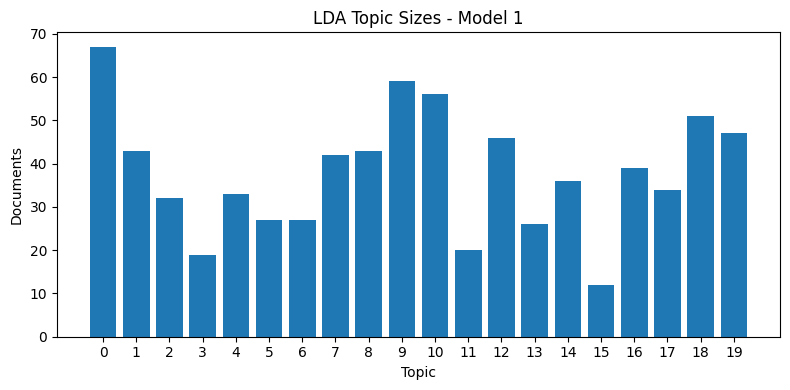

In [53]:
### Topic Size Comparison of Top X or Selected Models (Visual)

#for i in range(5):
#    row = lsa_tuning_interpreted_by_lang["en"].iloc[i]
#        
#    plot_topic_sizes(
#        doc_topic_matrix=row["doc_topic_matrix"],
#        method="lsa",
#        title=f"LSA Model {i}"
#    )
    
#plot_topic_sizes(
#    doc_topic_matrix=best_row["doc_topic_matrix"],
#    method="lsa",
#    title="LSA Topic Sizes"
#)

#for i in range(5):
row = lda_tuning_interpreted_by_lang["de"].iloc[0]
    
plot_topic_sizes(
    doc_topic_matrix=row["doc_topic_matrix"],
    method="lda",
    title=f"LDA Topic Sizes - Model {1}"
)


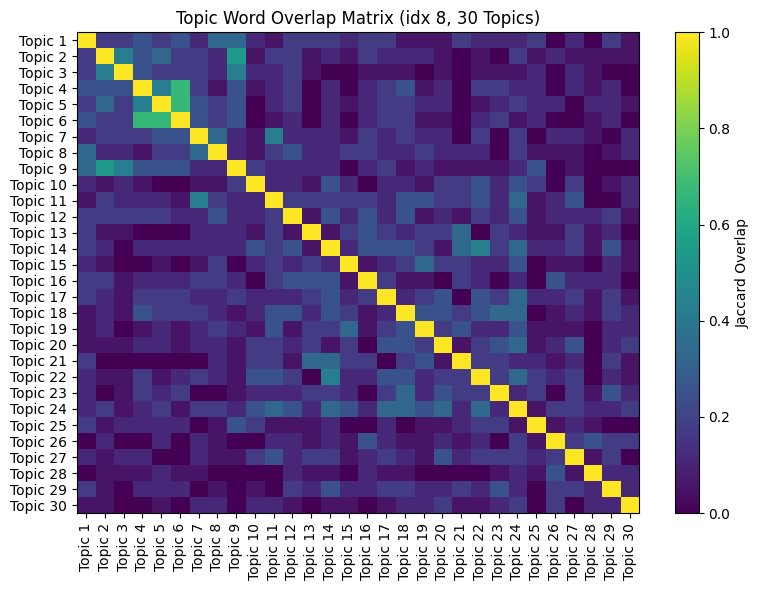

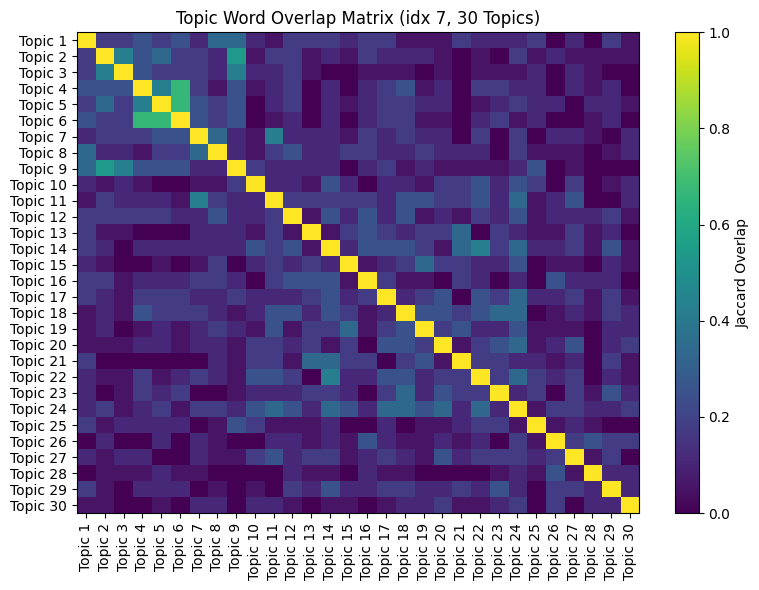

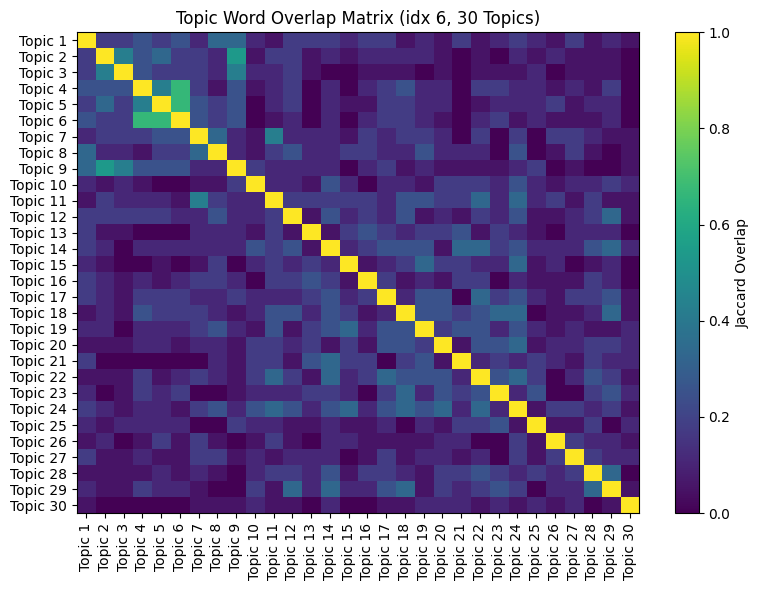

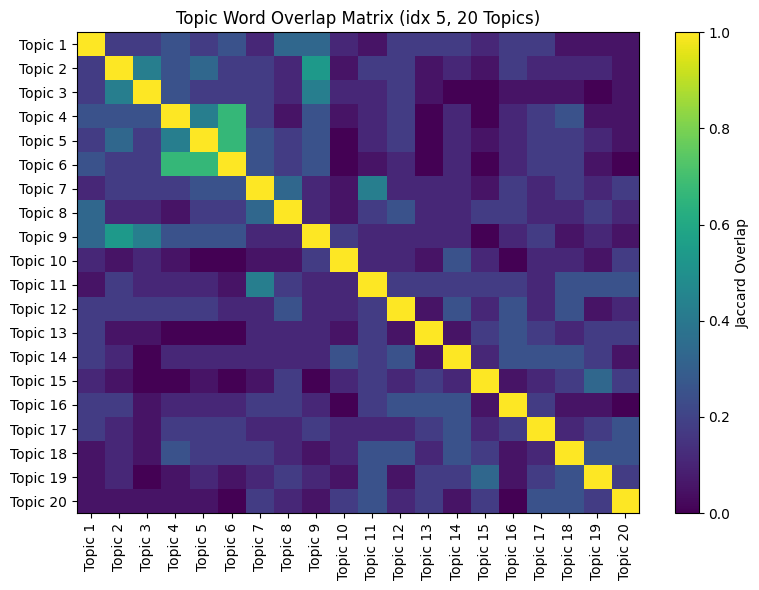

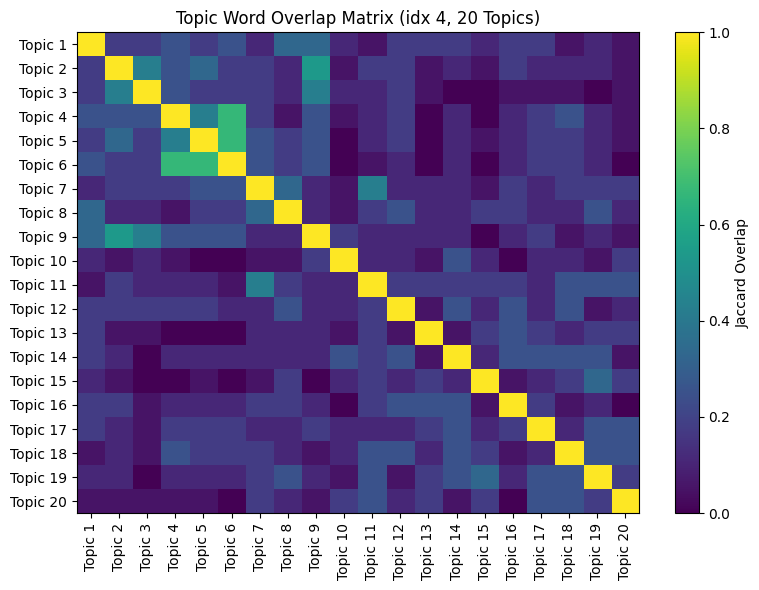

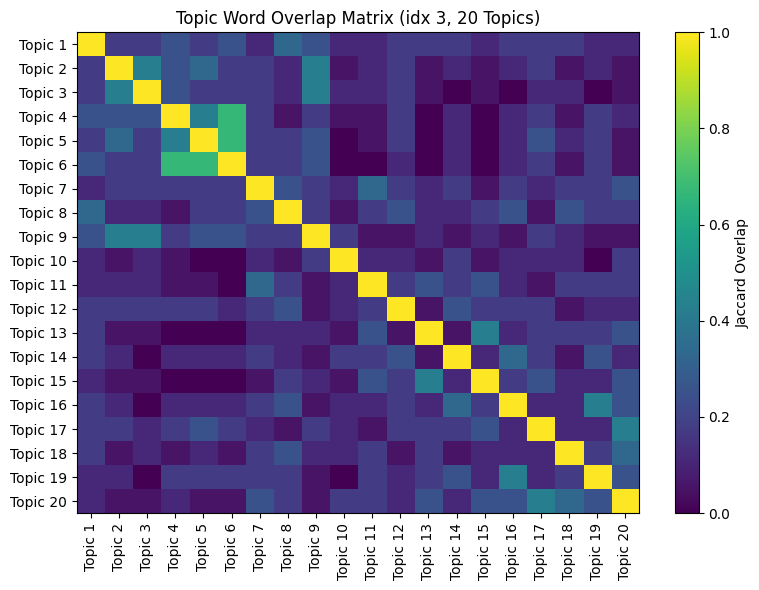

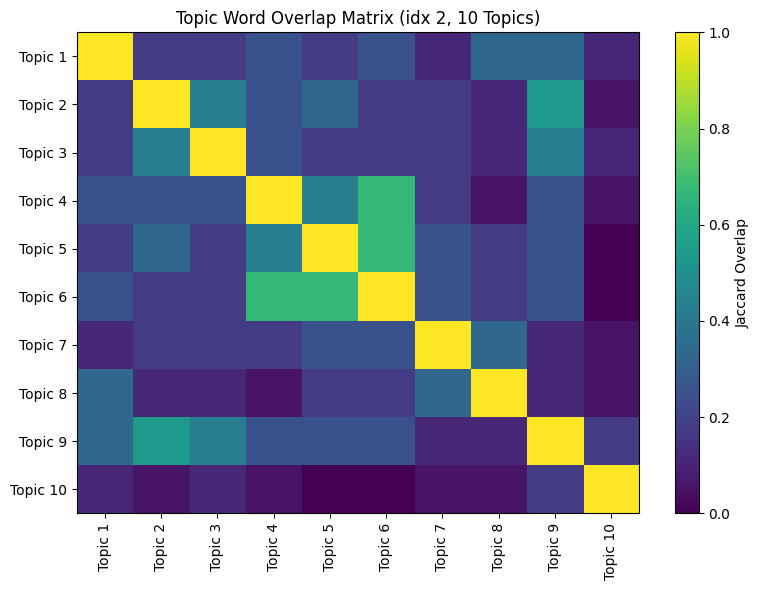

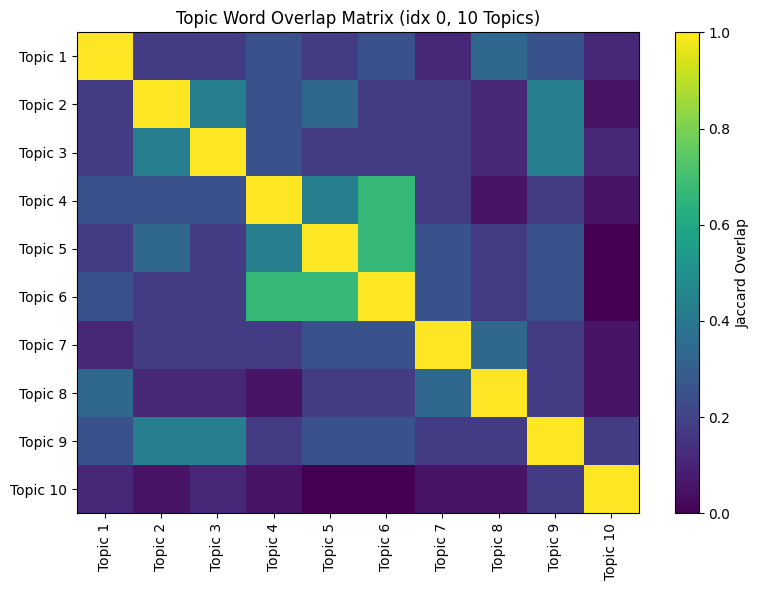

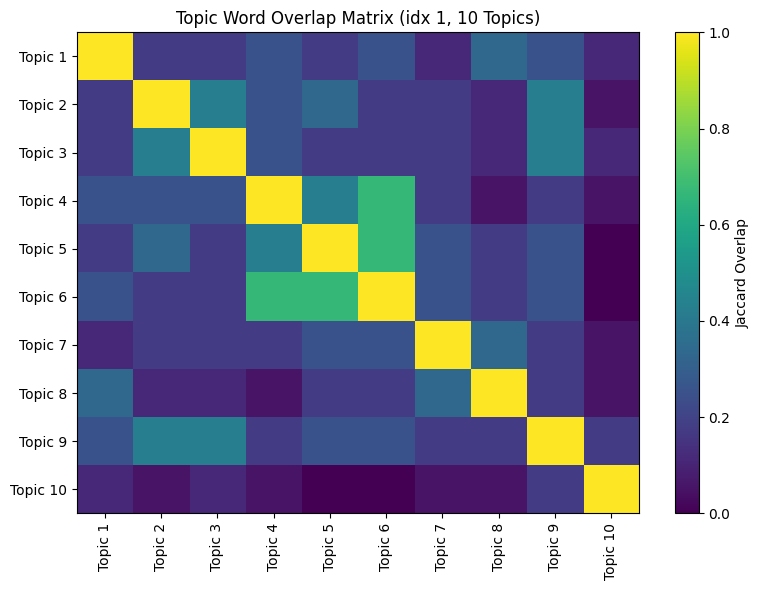

In [26]:
# Displays the overlap of top keywords between topics.
# Purpose:
# - Identify redundant or highly similar topics.
# - Assess whether the number of topics is too high.
# - Evaluate the degree of topic separation.

plot_topic_overlap_matrix(
    lsa_tuning_interpreted_by_lang["en"]
)

In [54]:
############
# FINAL TOPIC + SENTIMENT PIPELINE
# Separate Vector Spaces:
# - Topic Modeling: captures semantic structure of documents
# - Sentiment Analysis: captures emotional polarity independently
############

# 1. Manually Select Final Models
# Select best-performing configurations based on prior evaluation.
# Each selection defines:
# - modeling approach (LDA or LSA)
# - chosen parameter configuration (row)
# - corresponding vector spaces for topic and sentiment analysis
selected_models = {

    "de": {
        "method": "lda",
        "title": "LDA BoW (de)",

        # Manually selected model (not necessarily top-ranked)
        "row": lda_tuning_interpreted_by_lang["de"].iloc[0],

        # Use Bag-of-Words representation for both tasks
        "vector_topic": vectors_topic["bow_by_lang"]["de"],
        "vector_sentiment": vectors_sentiment["bow_by_lang"]["de"],
    },

    "en": {
        "method": "lda",
        "title": "LDA BoW (en)",

        # Manually selected model (not necessarily top-ranked)
        "row": lda_tuning_interpreted_by_lang["en"].iloc[0],

        # Use TF-IDF representation for both tasks
        "vector_topic": vectors_topic["bow_by_lang"]["en"],
        "vector_sentiment": vectors_sentiment["bow_by_lang"]["en"],
    }
}

# 2. Extract Final Topic Models
# Retrieve model components (topic terms, document-topic matrix, features)
# for the selected configurations
fitted_models = {}

for lang, selection in selected_models.items():
    fitted_models[lang] = get_selected_topic_model(selection)

# 3. Determine Dominant Topic per Document
# For each document:
# - Identify the most relevant (dominant) topic
# - Compute topic strength
doc_topics = {}

for lang, selection in selected_models.items():

    result = get_selected_topic_model(selection)

    doc_topics[lang] = compute_dominant_topics(
        doc_topic_matrix=result["doc_topic_matrix"],
        documents=result["documents"],
        method=selection["method"]
    )

# 4. Sentiment Analysis
# Compute sentiment score and label (positive / neutral / negative)
# for each document, independent of topic modeling
sentiments = {}

for lang, selection in selected_models.items():

    sentiments[lang] = build_sentiment_df(
        selection["vector_sentiment"],
        lang=lang
    )

# 5. Merge Topic + Sentiment
# Combine topic assignments with sentiment results
# to associate each document with both semantic and emotional information
doc_topics_sentiment = {}

for lang in doc_topics.keys():

    doc_topics_sentiment[lang] = merge_topic_sentiment(
        doc_topics[lang],
        sentiments[lang]
    )

# 6. Aggregate Topic + Sentiment Matrix
# Compute aggregated statistics per topic:
# - number of documents
# - average topic strength
# - average sentiment score
# - distribution of sentiment labels
topic_sentiment_summary = {}

for lang, df in doc_topics_sentiment.items():

    topic_sentiment_summary[lang] = build_topic_sentiment_summary(df)


# 7. Display Final Topic + Sentiment Matrices

for lang, summary_df in topic_sentiment_summary.items():

    selection = selected_models[lang]
    topic_terms = selection["row"]["topic_terms"]

    summary_display = summary_df.copy()

    # Top words per topic
    topic_keywords = {
        int(topic_name.split()[-1]) - 1: ", ".join(
            term["word"] for term in terms
        )
        for topic_name, terms in topic_terms.items()
    }

    summary_display["top_words"] = (
        summary_display["dominant_topic"]
        .map(topic_keywords)
    )

    print(f"\n=== Topic + Sentiment Vergleich ({lang}) ===")

    display(
        style_topic_sentiment(
            summary_display,
            f"{selection['title']} - Topic & Sentiment Matrix",
            pos_threshold=0.05,
            neg_threshold=-0.05
        )
    )


=== Topic + Sentiment Vergleich (de) ===


dominant_topic,documents,avg_topic_strength,avg_sentiment,positive,neutral,negative,top_words
1,67,0.744900,0.633942,54,10,3,"schlachtbetrieb, genehmigungsbescheide schlachtbetrieb, genehmigungsbescheide, digital, extern, unterbringung, dienstleister, extern dienstleister, prüfung, kommunikation"
2,43,0.876882,0.195686,13,27,3,"haus, zpo, krankenhaus, allgemein, hintergrund, unterstützung, wissenschaftlich, bay, erheblich, innerhalb"
3,32,0.855875,0.546072,22,8,2,"arzt, meldung, verdacht, biber, gebiet, medizinisch, unterweisung, unerwünscht, hintergrund, verpﬂichten"
4,19,0.873463,0.624395,14,4,1,"freistaat, notfallsanitäterinn, notfallsanitäterinn notfallsanitäter, notfallsanitäter, ausbildung, maßnahme, störfälle, erwartend, konzept, teilweise"
5,33,0.902890,0.427558,18,15,0,"bundesland, einrichtung, verwaltungsvorschrift, schwärzen, regelung, unterbringung, nutzung, frau, berlin, stgb"
6,27,0.840368,0.298611,12,13,2,"nächster, schreiben, planen, erlauben, landeshauptstadt, entscheidung, sprechen, kultur, finden, verfügung"
7,27,0.928680,0.486178,14,12,1,"account, mitglied, waffenschein, verfassungsfeindlich, überprüfen, afd, verfassungsschutz, vereinigung, frau, kontrolle"
8,42,0.798422,0.425226,22,16,4,"maßnahme, kosten, politisch, einsatz, stadt, universität, staatlich, kontrolle, tragen, ministerium"
9,43,0.843862,0.440770,24,17,2,"gemeinde, bayrischzell, sudelfeld, aufgabe, fach, landratsamt, erwartungshorizonte, aufgabe erwartungshorizonte, erwartungshorizonte fach, gemeinde bayrischzell"
10,59,0.879487,0.490493,39,19,1,"tier, überwachung, tierart, schlachthof, dokumentiert geschlachtet, geschlachtet, geschlachtet tier, dokumentiert, abgeschlossen, abgeschlossen berichtsjahr"



=== Topic + Sentiment Vergleich (en) ===


dominant_topic,documents,avg_topic_strength,avg_sentiment,positive,neutral,negative,top_words
1,60,0.763260,0.753507,52,5,3,"pizza, wine, order, burger, thai, service, fresh, live, beer, shrimp"
2,65,0.758577,0.726685,55,7,3,"food, service, fry, wait, table, crab, bar, order, salad, sandwich"
3,78,0.774722,0.744591,67,8,3,"food, menu, price, restaurant, salad, staff, cheese, sandwich, home, service"
4,61,0.746208,0.550569,42,11,8,"food, steak, eat, order, potato, service, breakfast, salad, table, make"
5,59,0.793382,0.661569,48,7,4,"hair, nail, owner, salon, cut, staff, pick, food, line, appointment"
6,48,0.693082,0.632933,36,7,5,"order, seafood, experience, wedding, restaurant, wait, night, dog, eat, cake"
7,58,0.726749,0.718950,50,6,2,"service, cream, ice, walk, ice cream, small, coffee, table, open, arrive"
8,53,0.743468,0.707658,46,3,4,"burger, roast, wait, menu, star, cake, tire, experience, coffee, table"
9,43,0.772736,0.759205,38,4,1,"car, service, customer, roll, sushi, sale, shop, customer service, bring, price"
10,43,0.718295,0.682928,35,6,2,"order, food, table, service, bread, wait, fresh, drink, beer, restaurant"


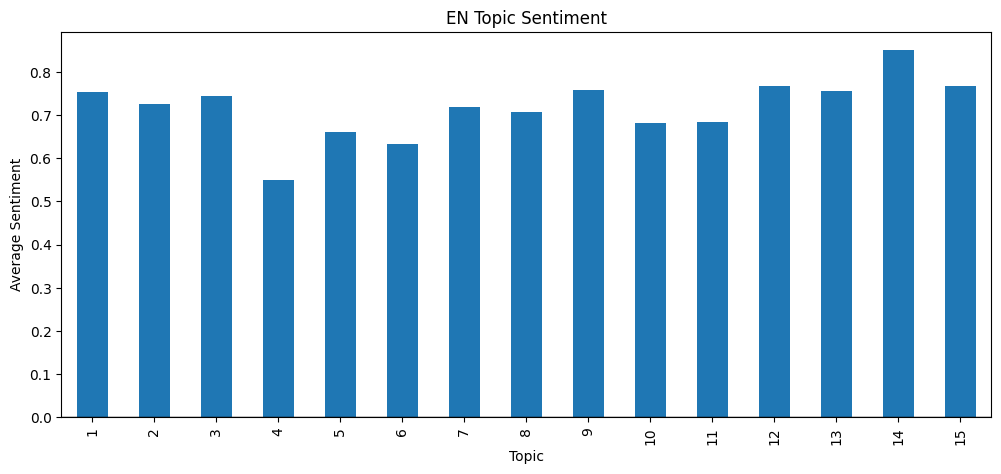

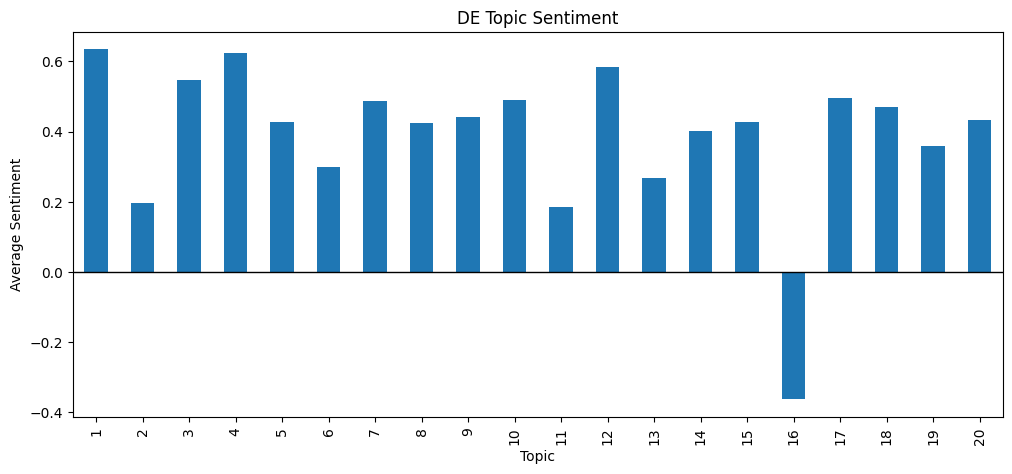

In [55]:
# Displays the average sentiment score for each topic.
# Purpose:
# - Identify topics with predominantly positive or negative sentiment.
# - Detect emotionally polarized topics.
# - Compare topics in terms of their semantic content and sentiment.

plot_topic_sentiment(
    topic_sentiment_summary["en"],
    title="EN Topic Sentiment"
)

plot_topic_sentiment(
    topic_sentiment_summary["de"],
    title="DE Topic Sentiment"
)

In [59]:
# Displays representative documents for a selected topic and sentiment class.
# Purpose:
# - Validate the semantic coherence of the discovered topic.
# - Assess whether the assigned documents match the topic keywords.
# - Verify whether the sentiment classification is consistent with the document content.
# - Support the qualitative evaluation of the topic model.
pd.set_option("display.max_colwidth", 1000)
show_reviews_for_topic(
    doc_topics_sentiment,
    lang="de",
    topic_id=1,
    sentiment_label="negative",
    n=10
)

,doc_id,dominant_topic,topic_strength,sentiment_score,sentiment_label,document_topic
362,362,1,0.996557,-0.8689,negative,beschwerde patient cfs jährlich landesärztekammer untergliedert kammer richten klarstellung vorliegen cfs aussage patient ausgehen ärztlich meinung patient beschwerde einlegen beschwerde formal annehmen ablehnen weiterverfolgen erfasst patient cfs post covid explizit psychosomatisch funktionell einstufen vergeben patient angefochten beschwerde zählen förmlich einreichen telefonisch schriftlich formular kontaktwege eingehen einstellen beschwerde rechtlich arzt patient abmahnung berufsrechtlich sanktion rug geldbuße entzug approbation beschwerde systematisch diagnosebezug cfs erfasst zuordnung vornehmen beschwerde insgesamt unabhängig cfs einordnung zahl aufschlüsselung beschwerde maßnahme systematisch einleiten
194,194,1,0.994751,-0.7430,negative,august zahl zuständigkeitsbereich registriert lebensmittelbetrieb august zahl zuständigkeitsbereich registriert kontrollierend betrieb bedarfsgegenständer kosmetik tabakerzeugnisse herstellen lebensmittelkontrolleur august überwachung betrieb betrauen vollzeitäquivalente fte berücksichtigung avv rüb durchzuführend risikobeurteilung routinekontrolle lebensmittelbetriebe august zuständigkeitsbereich maßgabe avv rüb kontrollhäufigkeit zahl august tatsächlich erfolgt routinekontrolle lebensmittelbetriebe verstoß zuständigkeitsgebiet lfgb veröffentlichen august häufig august bußgeld lfgb verhängen bußgeld überprüfen werbung social media antworten plattform gesundheitsbezogen werbeaussag august bewerten unzulässig befinden
230,230,1,0.940623,-0.6597,negative,patient medikation lockern entlassen patient fehleinweisung entlassen patient hospitalisierung erkranken
